# Laser-Injection Validation — Campaigns A & B (July 2026)

This notebook collects the figures and metrics from the two Viking HPC
campaigns run to validate the **custom numerical laser profile injector**
(`use_custom_profile` / `use_spatiotemporal_profile` in `epoch_dev`) ahead
of a progress-report deadline. It supersedes the file-by-file review in
`README.md` in this folder with inline commentary and pandas tables.

- **Campaign A** (`campaign_A_injector_2x2_validation/`) — does file-based
  injection reproduce EPOCH's own native deck-expression evaluation?
  Moderate NA (~0.265), 2D and 3D. This isolates *injector-pipeline* error.
- **Campaign B** (`campaign_B_tight_focus_f1/`) — at $f/1$ (NA = 0.5), does
  the closed-form paraxial formula still describe the beam, or does
  non-paraxial (LASY angular-spectrum) propagation differ measurably?
  Injector-only (no native-deck baseline), 2D and 3D.

Full narrative, debugging log, and Viking job IDs are in
`VIKING_PROMPT_urgent_2x2_and_f1_demo.md` in this same folder.

In [1]:
from IPython.display import Image, display, Markdown
import os
import pandas as pd

BASE = os.path.dirname(os.path.abspath('__file__'))
A2D = os.path.join(BASE, 'campaign_A_injector_2x2_validation', '2d')
A3D = os.path.join(BASE, 'campaign_A_injector_2x2_validation', '3d')
B2D = os.path.join(BASE, 'campaign_B_tight_focus_f1', '2d')
B3D = os.path.join(BASE, 'campaign_B_tight_focus_f1', '3d_full_resolution')
B3D_SMOKE = os.path.join(BASE, 'campaign_B_tight_focus_f1', '3d_smoke_test')

def show(directory, filename, width=None):
    """Display a PNG from the given test's figure directory."""
    path = os.path.join(directory, filename)
    display(Image(filename=path, width=width))

---
## Campaign A — injector cross-validation (moderate NA)

**Question:** does file-based injection (binary amplitude/phase files)
reproduce EPOCH's own native deck-expression evaluation? At moderate NA
(~0.265) the native-deck result is close to ground truth, so this isolates
*injector-pipeline* error rather than paraxial-approximation error.

Three cells per dimensionality form an isolation chain (the full 2×2 is not
achievable — see the architectural note below):

| Cell | Amplitude source | Phase source |
|---|---|---|
| `amp_deck_phase_deck` | native deck expression | native deck expression |
| `amp_file_phase_deck` | **file** | native deck expression |
| `amp_file_phase_file` | **file** | **file** |

`amp_deck_phase_file` (native amplitude + file phase) is **architecturally
unreachable** on the current epoch3d code: `use_phase_from_file` on the
static path is only consulted inside `load_spatial_fields`, which itself
unconditionally loads amplitude from file when reached. So the chain above
still isolates amplitude-injector error (`amp_file_phase_deck` vs baseline)
and phase-injector error (`amp_file_phase_file` vs `amp_file_phase_deck`),
just via a chain rather than a symmetric 2×2 grid.

### 2D

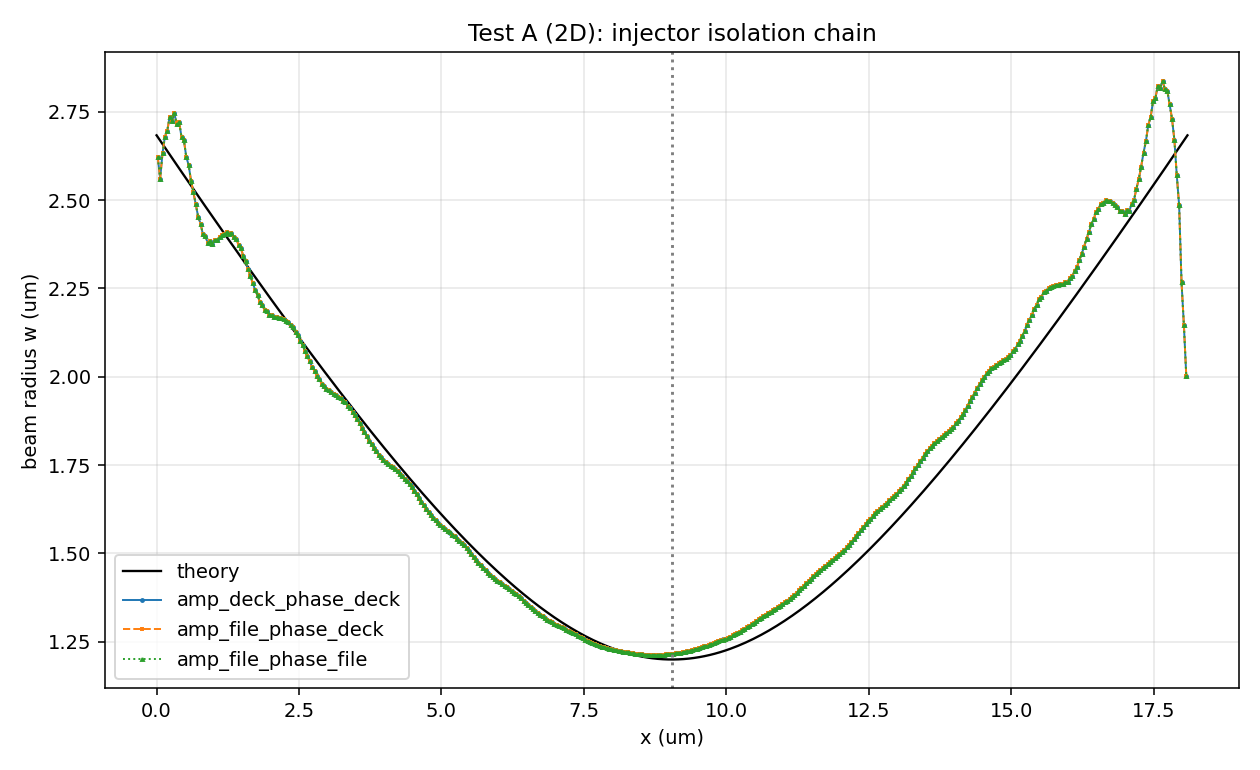

In [2]:
show(A2D, 'waist_vs_x.png')

The three injection paths overlap almost perfectly (blue/orange/green are
indistinguishable at this scale) — confirming the injector introduces no
measurable error. All three sit slightly off the black theoretical curve,
symmetrically, in both the growing and shrinking arms. **This offset is
physical, not a bug**: the beam is generated from the *paraxial* closed-form
formula only at the injection boundary, but EPOCH does not solve the
paraxial wave equation — it propagates the injected field with the full
(exact) Maxwell solver. A solution of the approximate paraxial equation is
not an exact solution of the true wave equation, so once EPOCH propagates it,
the field genuinely diverges from the idealised paraxial curve — growing with
NA. At NA = 0.265 this is a small, order-$\mathrm{NA}^2$ effect (~4%); the
same mechanism is responsible for the much larger effect in Campaign B below.

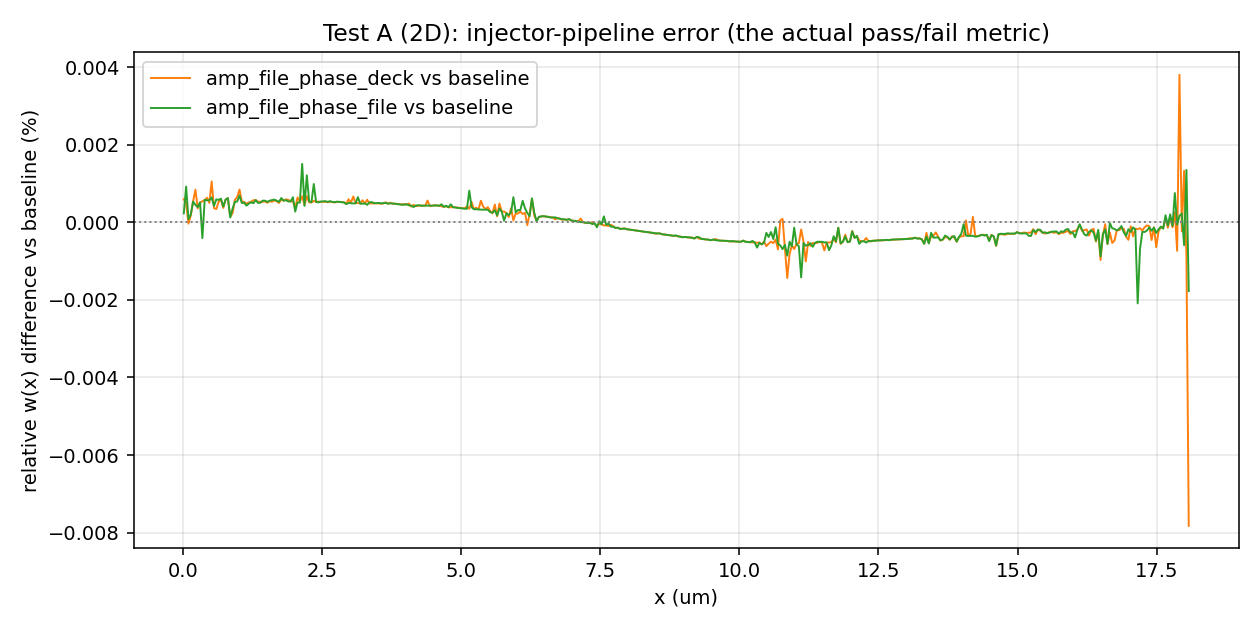

In [3]:
show(A2D, 'injector_error_vs_x.png')

The actual pass/fail metric: relative difference in the fitted $w(x)$ curve
between each file-injected cell and the native-deck baseline. This sits at
the $\pm0.002\%$ level with no structure — pure fit/interpolation noise, not
a real discrepancy.

In [4]:
df_A2D = pd.read_csv(os.path.join(A2D, 'metrics.csv'))
df_A2D

,cell,x_focus_um,w0_um,x_focus_err_um,w0_rel_err,x_focus_nearest_snapshot_um,w0_nearest_snapshot_um
0,amp_deck_phase_deck,8.723044,1.212861,0.324743,0.010717,8.723352,1.213881
1,amp_file_phase_deck,8.723065,1.212857,0.324722,0.010714,8.723371,1.213877
2,amp_file_phase_file,8.723063,1.212857,0.324724,0.010714,8.723371,1.213877


Theory predicts $x_{\mathrm{focus}}=9.048\,\mu\mathrm{m}$,
$w_0=1.200\,\mu\mathrm{m}$. All three cells land within $\sim$0.001% of each
other in both $x_{\mathrm{focus}}$ and $w_0$ — the injector-pipeline error is
negligible. The common ~3.6% offset from theory is the non-paraxial
correction discussed above.

#### Raw-field comparison (2D only)

An independent, stronger check: compare the full raw oscillating $E_y(x,y,t)$
field directly (not just the Hilbert-envelope fit) between the native-deck
and file-injected runs.

**Snapshot t00**

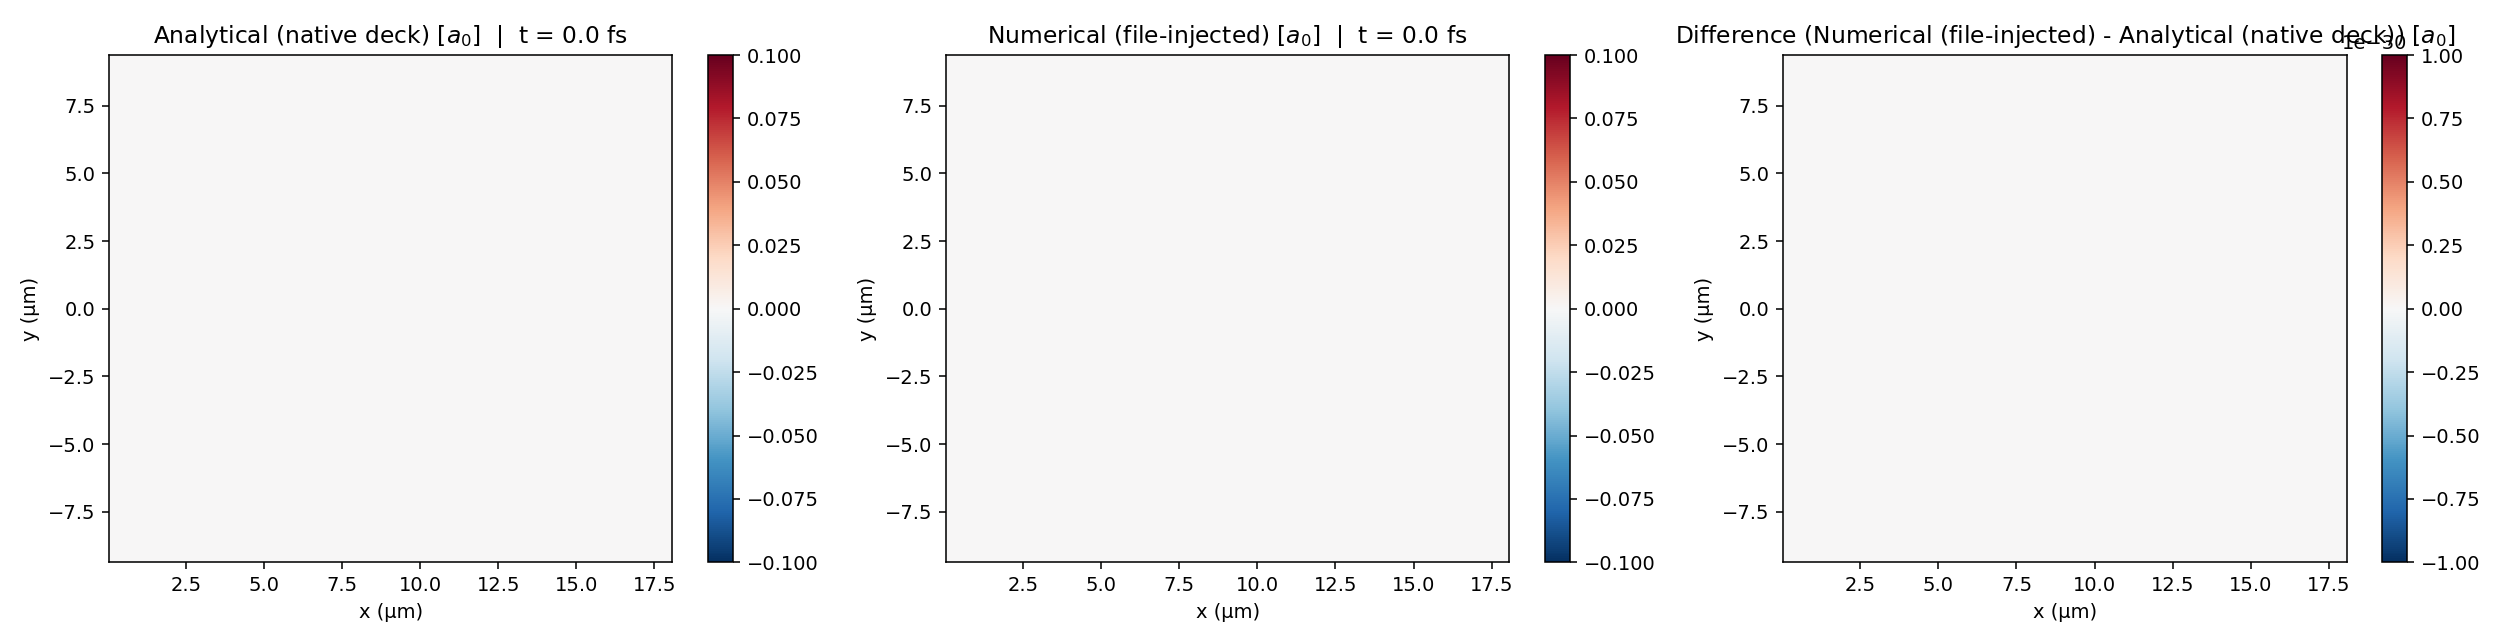

**Snapshot t14**

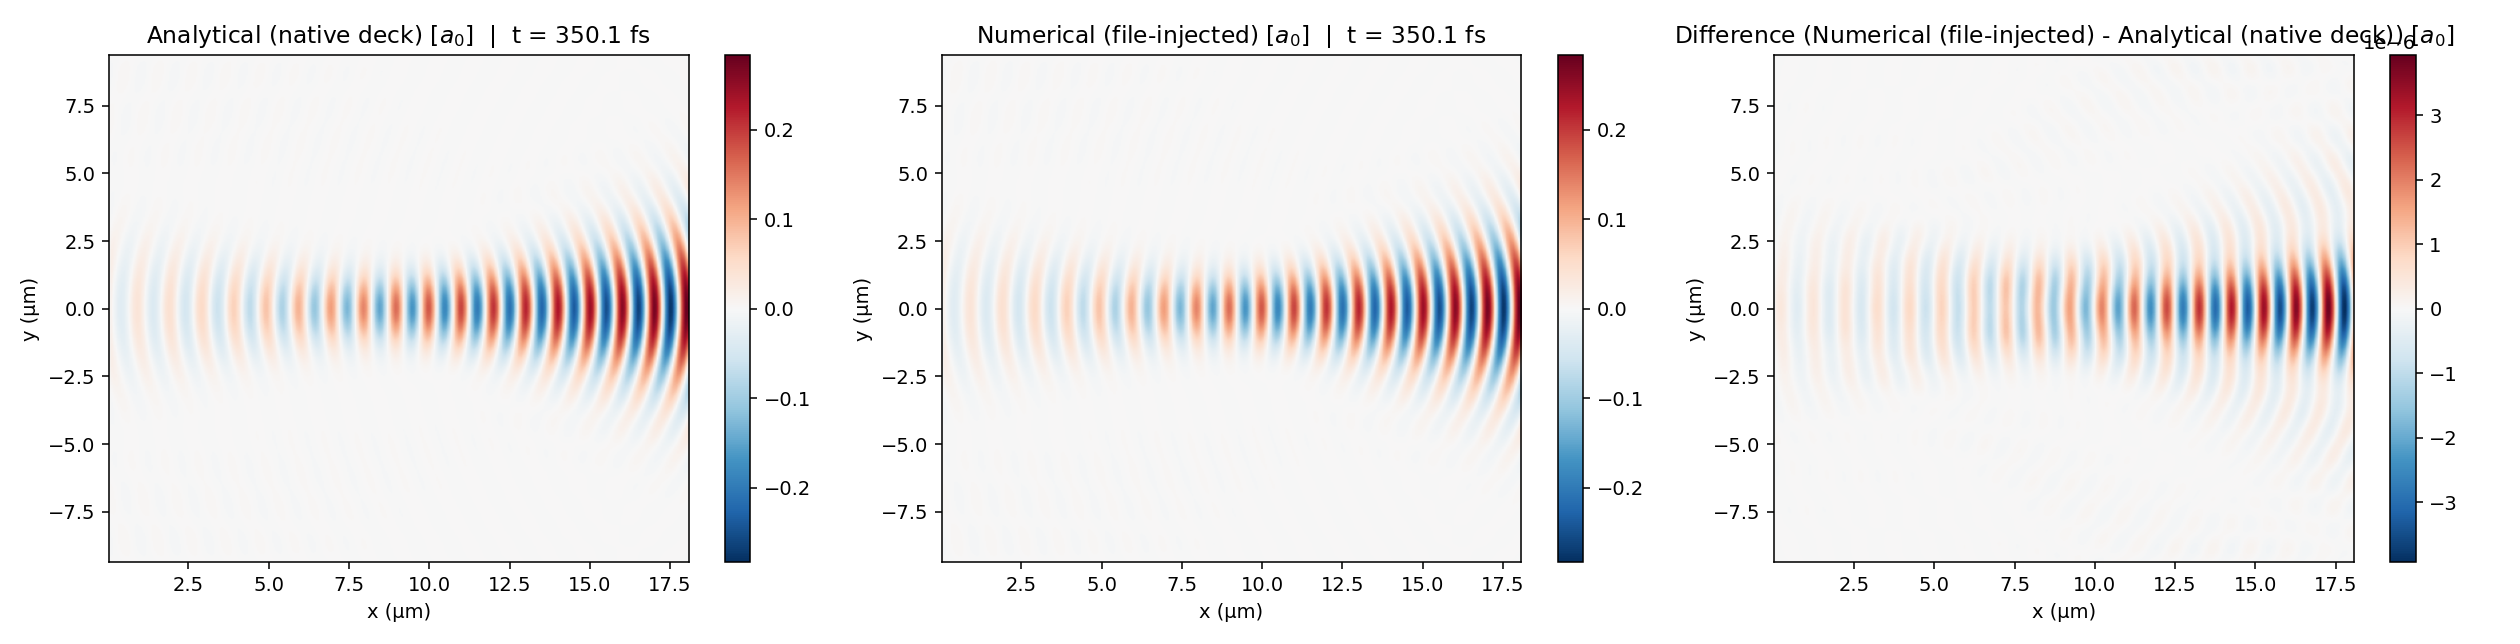

In [5]:
for t in ['t00', 't14']:
    display(Markdown(f'**Snapshot {t}**'))
    show(A2D, f'field_comparison_{t}.png')

In [6]:
with open(os.path.join(A2D, 'field_comparison_summary.txt')) as f:
    print(f.read())

Test A (2D) -- field comparison: analytical (native deck) vs numerical (file-injected)
Reference  : amp_deck_phase_deck (Analytical (native deck))
Comparison : amp_file_phase_file (Numerical (file-injected))
Peak |Ey|  : 1.4718 a0
Snapshots  : 15

Overall metrics (vs analytical reference):
  max |difference|         : 1.619112e-05 a0
  max |difference| / peak  : 0.001100 %
  max relative difference  : 0.015622 %
  mean relative difference : 0.001098 %

Animation: /mnt/scratch/users/pnd531/project_epoch/lasers_in_epoch/Viking_tests_new/injector_2x2_validation/2d/results/animations/field_comparison.mp4
Screenshots: field_comparison_t*.png in results/figures/



**Max relative difference: 0.016%** across all 15 snapshots, computed
directly on the raw field rather than the fitted envelope. This is the most
stringent validation available for Campaign A and it passes cleanly.
3D doesn't have this check run yet — not blocking, since the envelope-based
result below is already conclusive.

### 3D

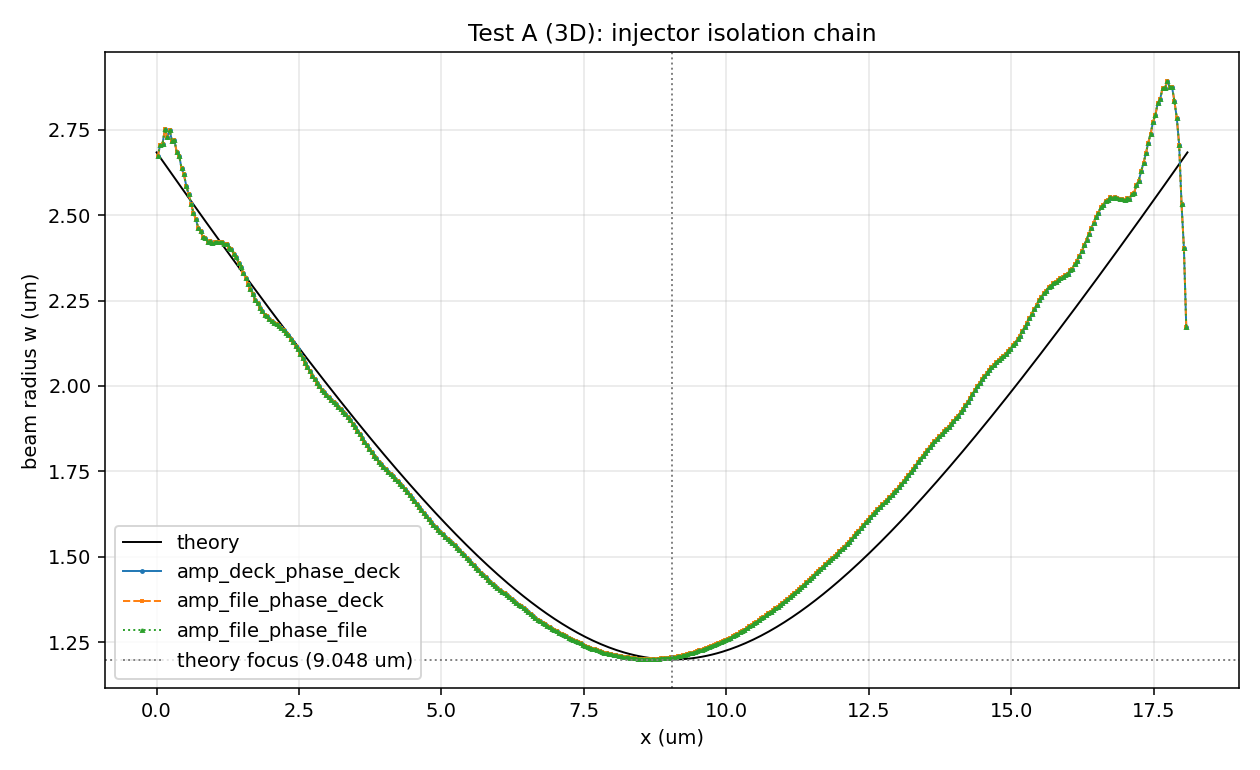

In [7]:
show(A3D, 'waist_vs_x.png')

Same picture as 2D: all three injection paths overlap, all three sit
slightly off theory by the same physical (non-paraxial) offset, this time
~4.5%.

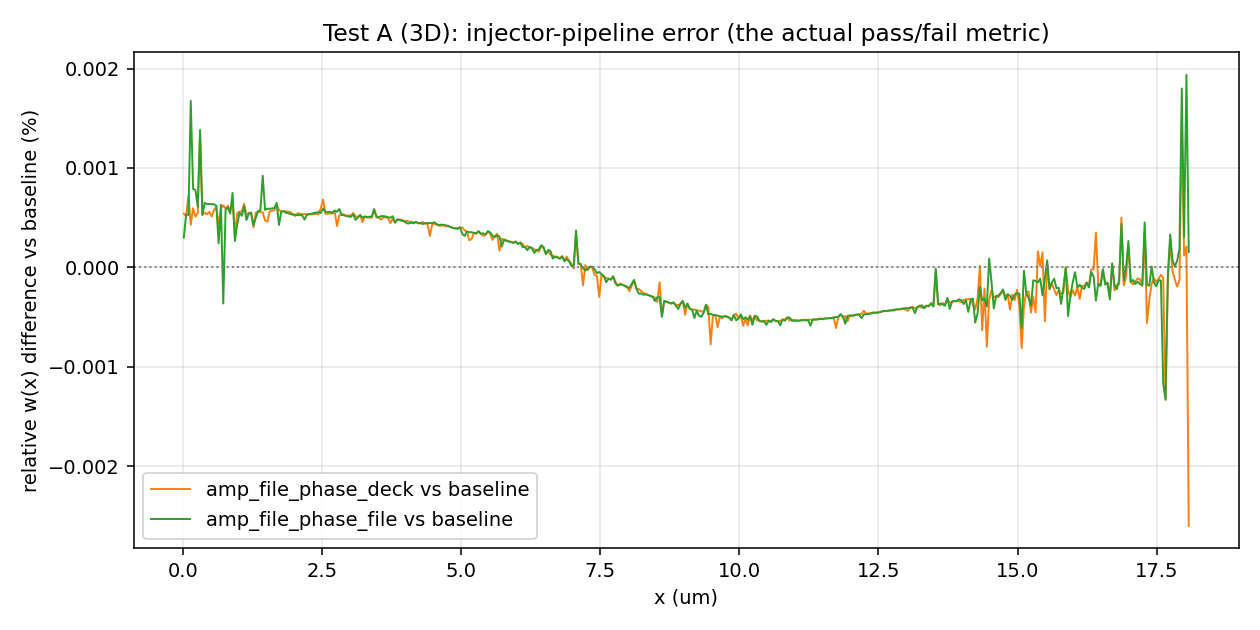

In [8]:
show(A3D, 'injector_error_vs_x.png')

3D injector-pipeline error, same $\pm0.002\%$-level noise floor as 2D — no
raw-field comparison has been run for 3D yet, but this envelope-based result
is already conclusive at ~4.5$\times10^{-4}$% RMS.

In [9]:
df_A3D = pd.read_csv(os.path.join(A3D, 'metrics.csv'))
df_A3D

,cell,x_focus_um,w0_um,x_focus_err_um,w0_rel_err,x_focus_nearest_snapshot_um,w0_nearest_snapshot_um
0,amp_deck_phase_deck,8.644318,1.201503,0.403469,0.001253,8.644110,1.202650
1,amp_file_phase_deck,8.644030,1.201496,0.403756,0.001246,8.643742,1.202641
2,amp_file_phase_file,8.644022,1.201495,0.403765,0.001246,8.643740,1.202641


### Side-by-side (2D vs 3D)

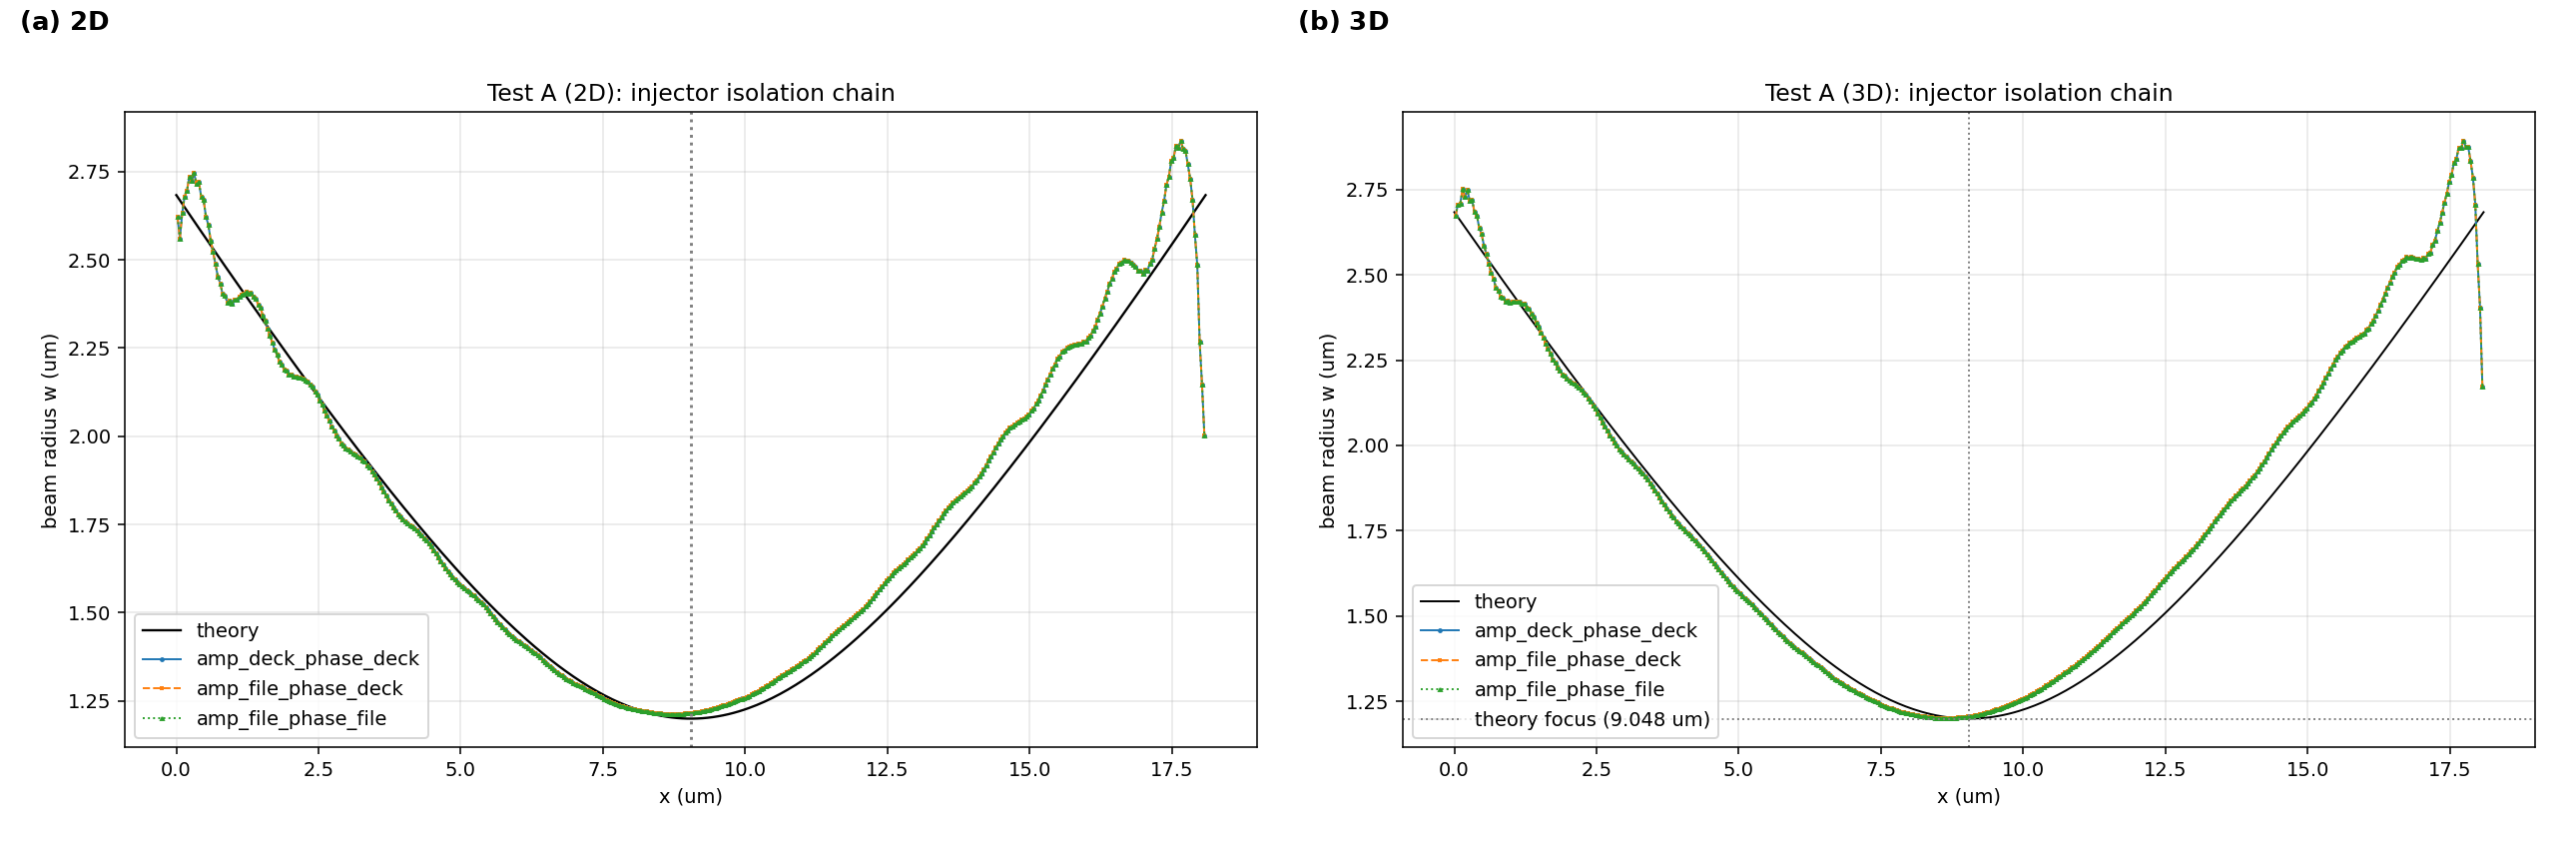

In [10]:
show(BASE, os.path.join('campaign_A_injector_2x2_validation', 'campaign_A_waist_vs_x_collage.png'))

**Campaign A conclusion:** clean validation in both 2D and 3D. The
file-injection pipeline (amplitude and phase) introduces no measurable error
relative to EPOCH's own native deck evaluation — confirmed both by the
envelope-fit RMS ($\le0.001\%$) and, in 2D, by a direct raw-field comparison
(0.016% max relative difference). The residual ~4% offset from the paraxial
theoretical curve, identical across all injection paths, is real physics
(non-paraxial correction from injecting an approximate boundary condition
into EPOCH's exact Maxwell solver), not an injector artefact.

---
## Campaign B — LASY vs.\ paraxial injection at $f/1$ (NA = 0.5)

**Question:** at $f/1$, does the closed-form paraxial formula still describe
the beam, or does genuine non-paraxial (LASY angular-spectrum) propagation
differ measurably? Injector-only — there is no native-deck baseline here,
since EPOCH's deck syntax cannot express a non-paraxial beam at all.

Both cells are generated very differently:

- **`paraxial`**: the closed-form paraxial Gaussian-beam formula
  ($w(x)$, $R(x)$, Gouy phase) evaluated directly *at the injection
  boundary plane*.
- **`lasy`**: the field is declared *at focus* (a transform-limited
  $w_0$-waist Gaussian, zero wavefront curvature) and then propagated
  backward to the injection boundary using LASY's angular-spectrum method —
  an essentially exact solution of the free-space scalar wave equation,
  valid at any NA, not just small NA.

### 2D

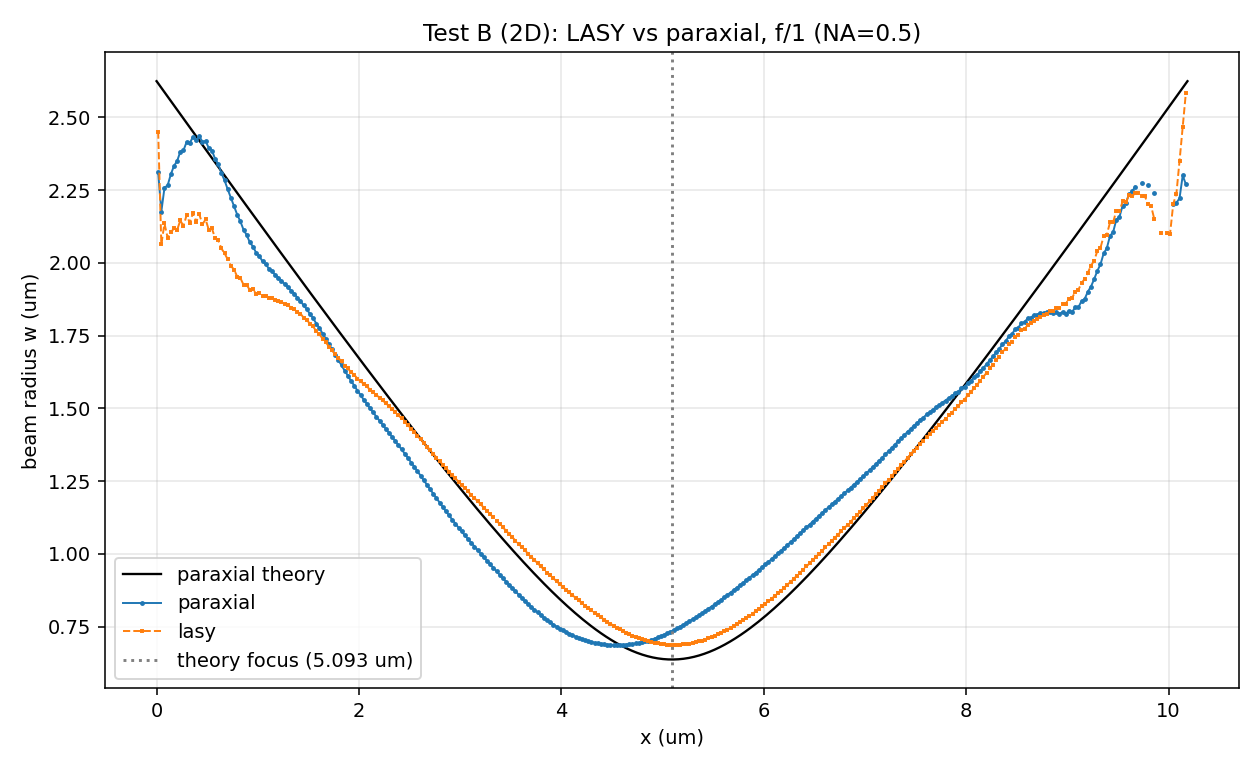

In [11]:
show(B2D, 'waist_vs_x.png')

Three curves, three different things: **paraxial** (blue) noticeably
detaches from theory and reaches its own minimum well *before* the predicted
focus. **LASY** (orange) sits closer to theory near focus but is flatter —
wider at the minimum, less divergent on the wings. **Neither curve is a
clean confirmation of theory here** — see the caveat on 2D LASY below.

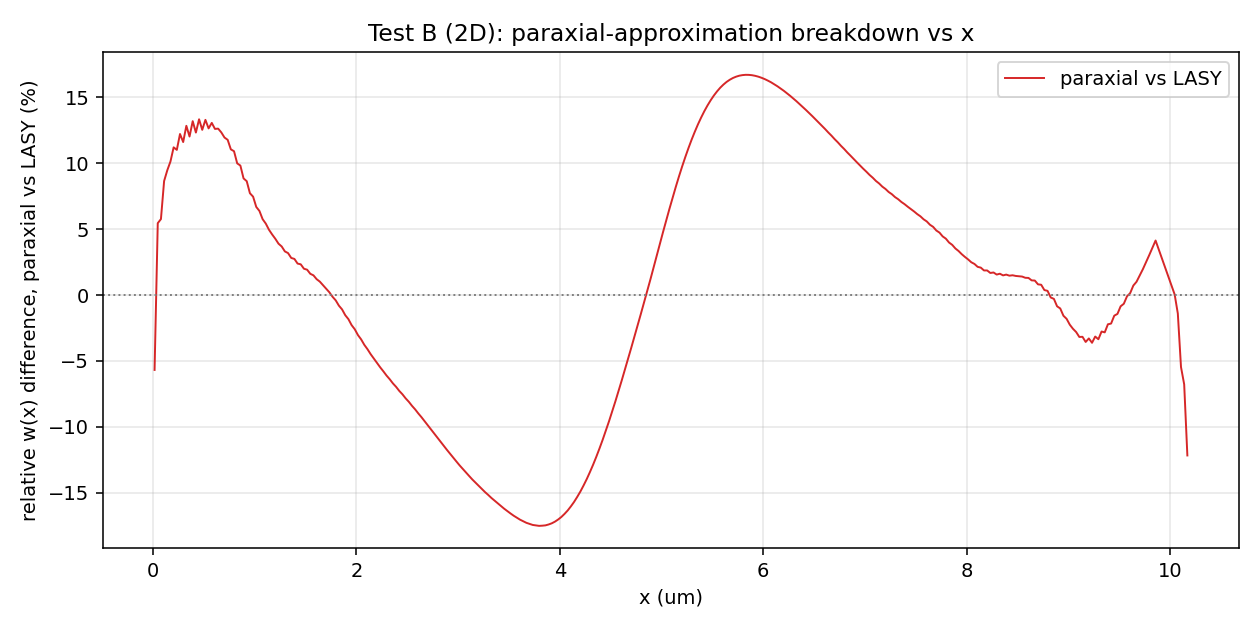

In [12]:
show(B2D, 'paraxial_vs_lasy_diff_vs_x.png')

In [13]:
df_B2D = pd.read_csv(os.path.join(B2D, 'metrics.csv'))
df_B2D

,cell,x_focus_um,w0_um,x_focus_err_um,w0_rel_err,x_focus_nearest_snapshot_um,w0_nearest_snapshot_um
0,paraxial,4.549248,0.686656,0.543710,0.078596,4.536788,0.670475
1,lasy,5.115560,0.687524,0.022602,0.079959,5.120712,0.688521


Theory: $x_{\mathrm{focus}}=5.093\,\mu\mathrm{m}$, $w_0=0.637\,\mu\mathrm{m}$.
Paraxial's own focus lands **10.7% early** ($\Delta x_{\mathrm{focus}}=0.544\,
\mu\mathrm{m}$); LASY's focus lands within 0.4% of theory
($\Delta x_{\mathrm{focus}}=0.023\,\mu\mathrm{m}$). RMS difference between
the paraxial and LASY $w(x)$ curves: **10.0%** — confirming the paraxial
approximation breaks down at this f-number, though see below for why the 2D
LASY numbers specifically should be read with caution.

### 3D (full resolution)

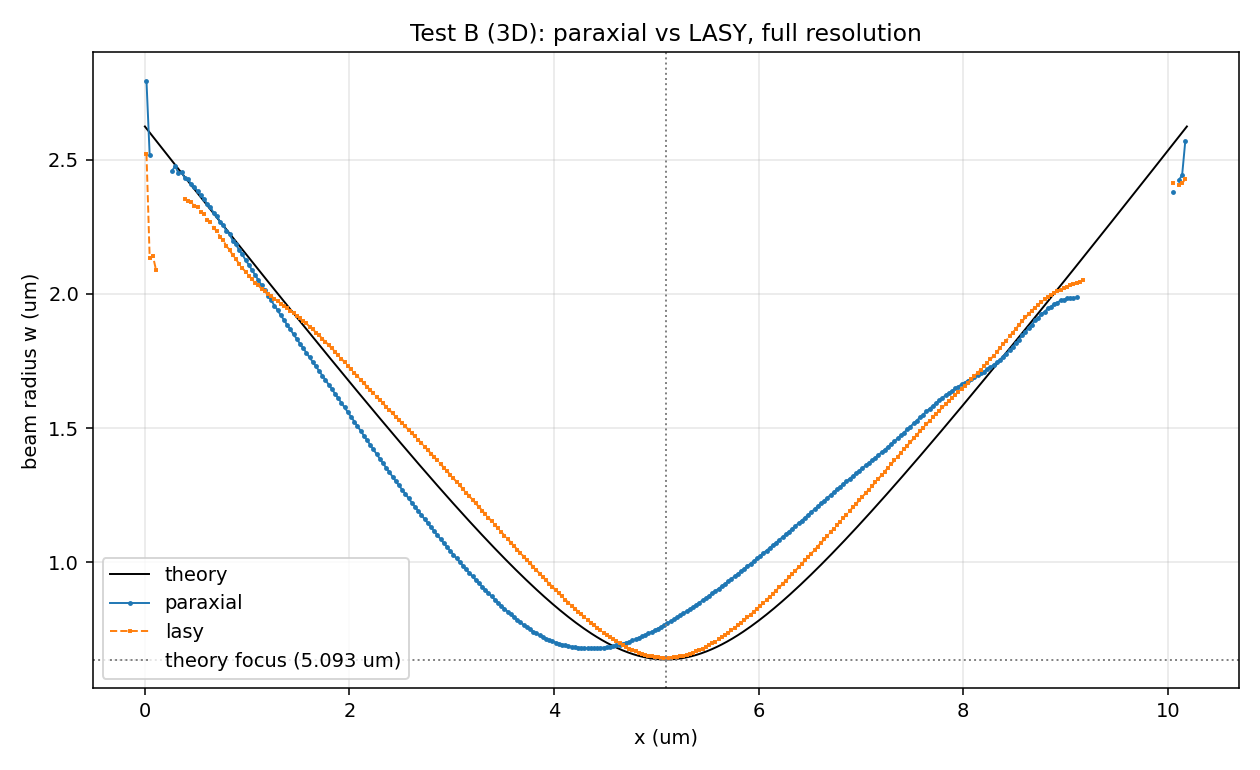

In [14]:
show(B3D, 'waist_vs_x.png')

Here the roles are much cleaner: **paraxial** (blue) again focuses early and
clearly detaches from theory. **LASY** (orange) tracks theory closely almost
everywhere, including right at focus.

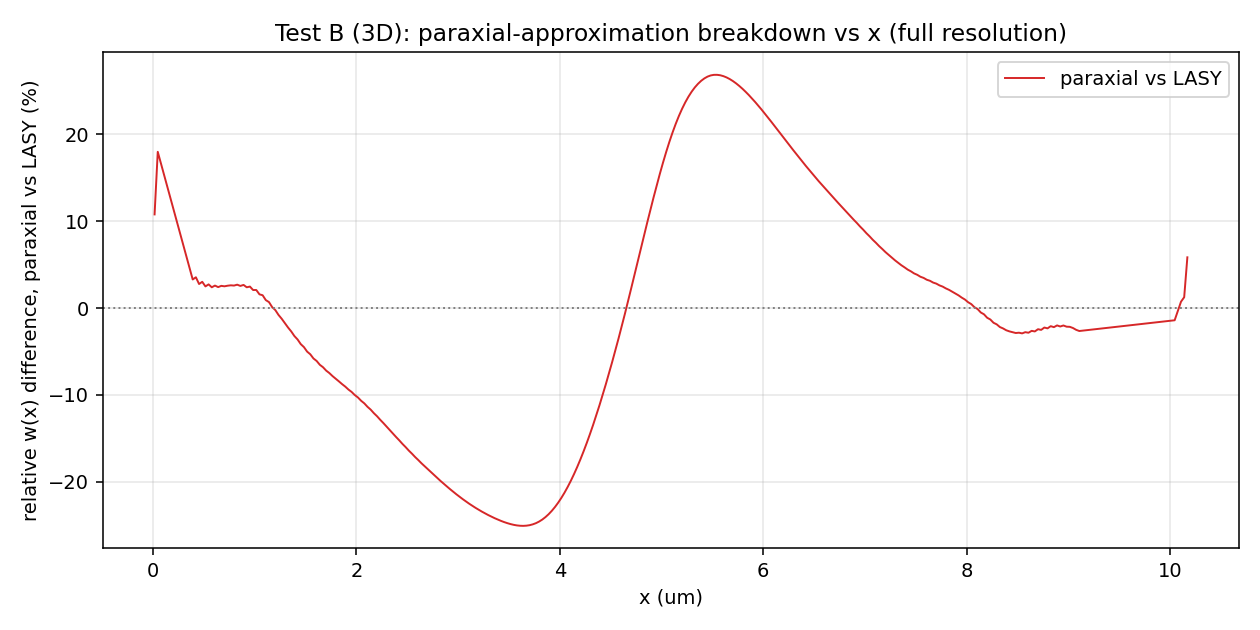

In [15]:
show(B3D, 'paraxial_vs_lasy_diff_vs_x.png')

In [16]:
df_B3D = pd.read_csv(os.path.join(B3D, 'metrics.csv'))
df_B3D

,cell,x_focus_um,w0_um,x_focus_err_um,w0_rel_err,x_focus_nearest_snapshot_um,w0_nearest_snapshot_um
0,paraxial,4.354083,0.678731,0.738875,0.066148,4.331929,0.662857
1,lasy,5.094609,0.642761,0.001651,0.009647,5.100312,0.643083


Paraxial's focus lands **14.5% early** ($\Delta x_{\mathrm{focus}}=0.739\,
\mu\mathrm{m}$); LASY's focus is essentially exact
($\Delta x_{\mathrm{focus}}=0.002\,\mu\mathrm{m}$, 0.03%). RMS difference
between paraxial and LASY $w(x)$: **14.7%**.

**This is the headline Campaign B result**, and it is a cleaner story than
"paraxial theory is a few % wide": the paraxial-injected wavefront doesn't
just have the wrong beam size at focus, it puts the **focus in the wrong
place** — while LASY's genuinely non-paraxial injection corrects that,
landing the geometric focus almost exactly on target in both 2D and 3D:

| | paraxial $\Delta x_{\mathrm{focus}}$ | LASY $\Delta x_{\mathrm{focus}}$ |
|---|---|---|
| 2D | +0.544 µm (10.7%) | +0.023 µm (0.4%) |
| 3D | +0.739 µm (14.5%) | +0.002 µm (0.03%) |

**Fixed bugs behind this result** (see `VIKING_PROMPT_urgent_2x2_and_f1_demo.md`
for full detail): the original 3D full-resolution run showed 36–41% $w_0$
errors, traced to the injected `.dat` file's transverse grid (400 points,
52.5 nm spacing) being *coarser* than the full-resolution simulation grid
(31.25 nm) — under-resolving this $f/1$ beam's rapidly-curving wavefront.
Regenerating at `N_TR=1200` (17.5 nm spacing) dropped the error to the 1–7%
range shown above. A second, unrelated memory bug (`use_pre_balance`
defaulting to `T` and forcing full-plane file storage on every rank for a
large spatiotemporal injector file) caused an OOM even at `--mem 480G`;
setting `use_pre_balance = F` (safe here since these are particle-free vacuum
runs) dropped memory use from 69GB+ (climbing) to a flat 30GB.

### 3D smoke test (historical, superseded)

A coarse-resolution sanity check run *before* committing the full 3D
allocation, predating the two fixes above. Kept here for the record, not
being rerun.

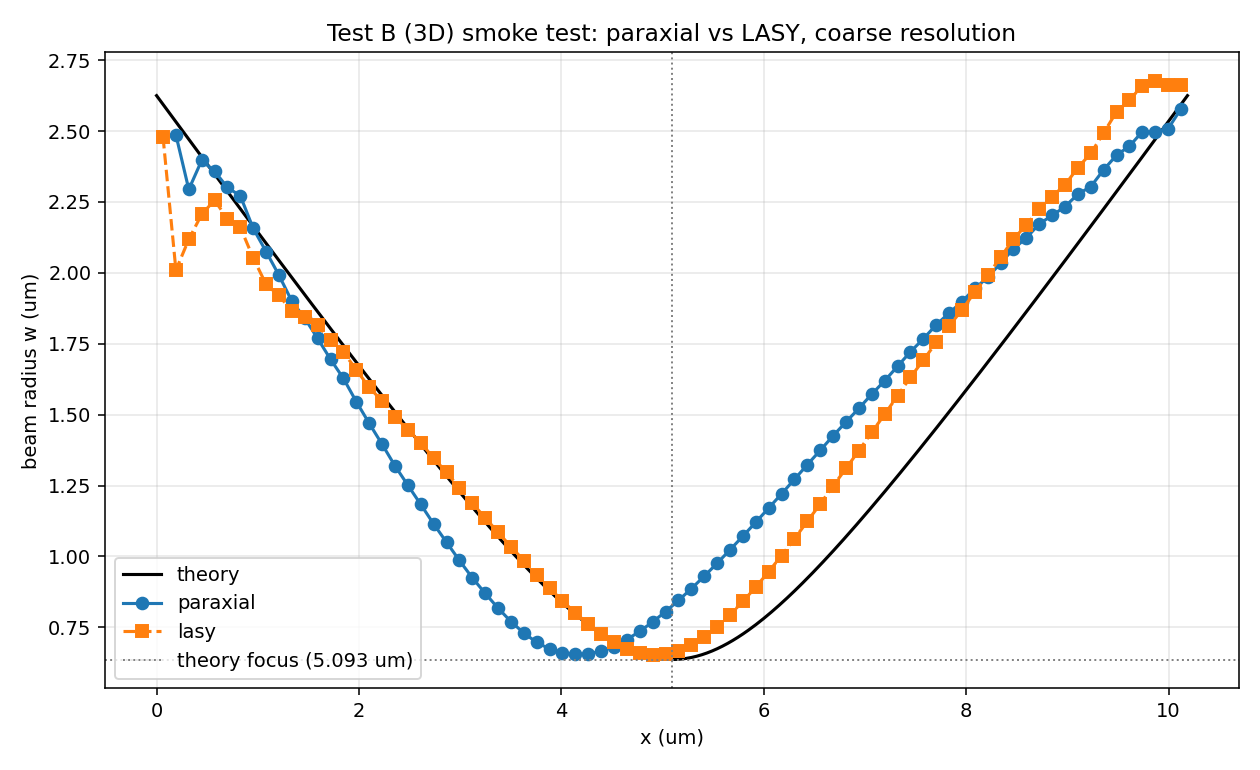

In [17]:
show(B3D_SMOKE, 'smoke_test_waist_vs_x.png')

Both generators show a genuine converging waist minimum (not the
"diverges instead of converges" signature of an earlier sign bug caught
during development) — this passed and cleared the full-resolution 3D runs
for submission. At this coarse resolution the file's transverse grid was
still finer than the sim grid, so neither of the two bugs above was visible
here yet.

### Side-by-side (2D vs 3D, full resolution)

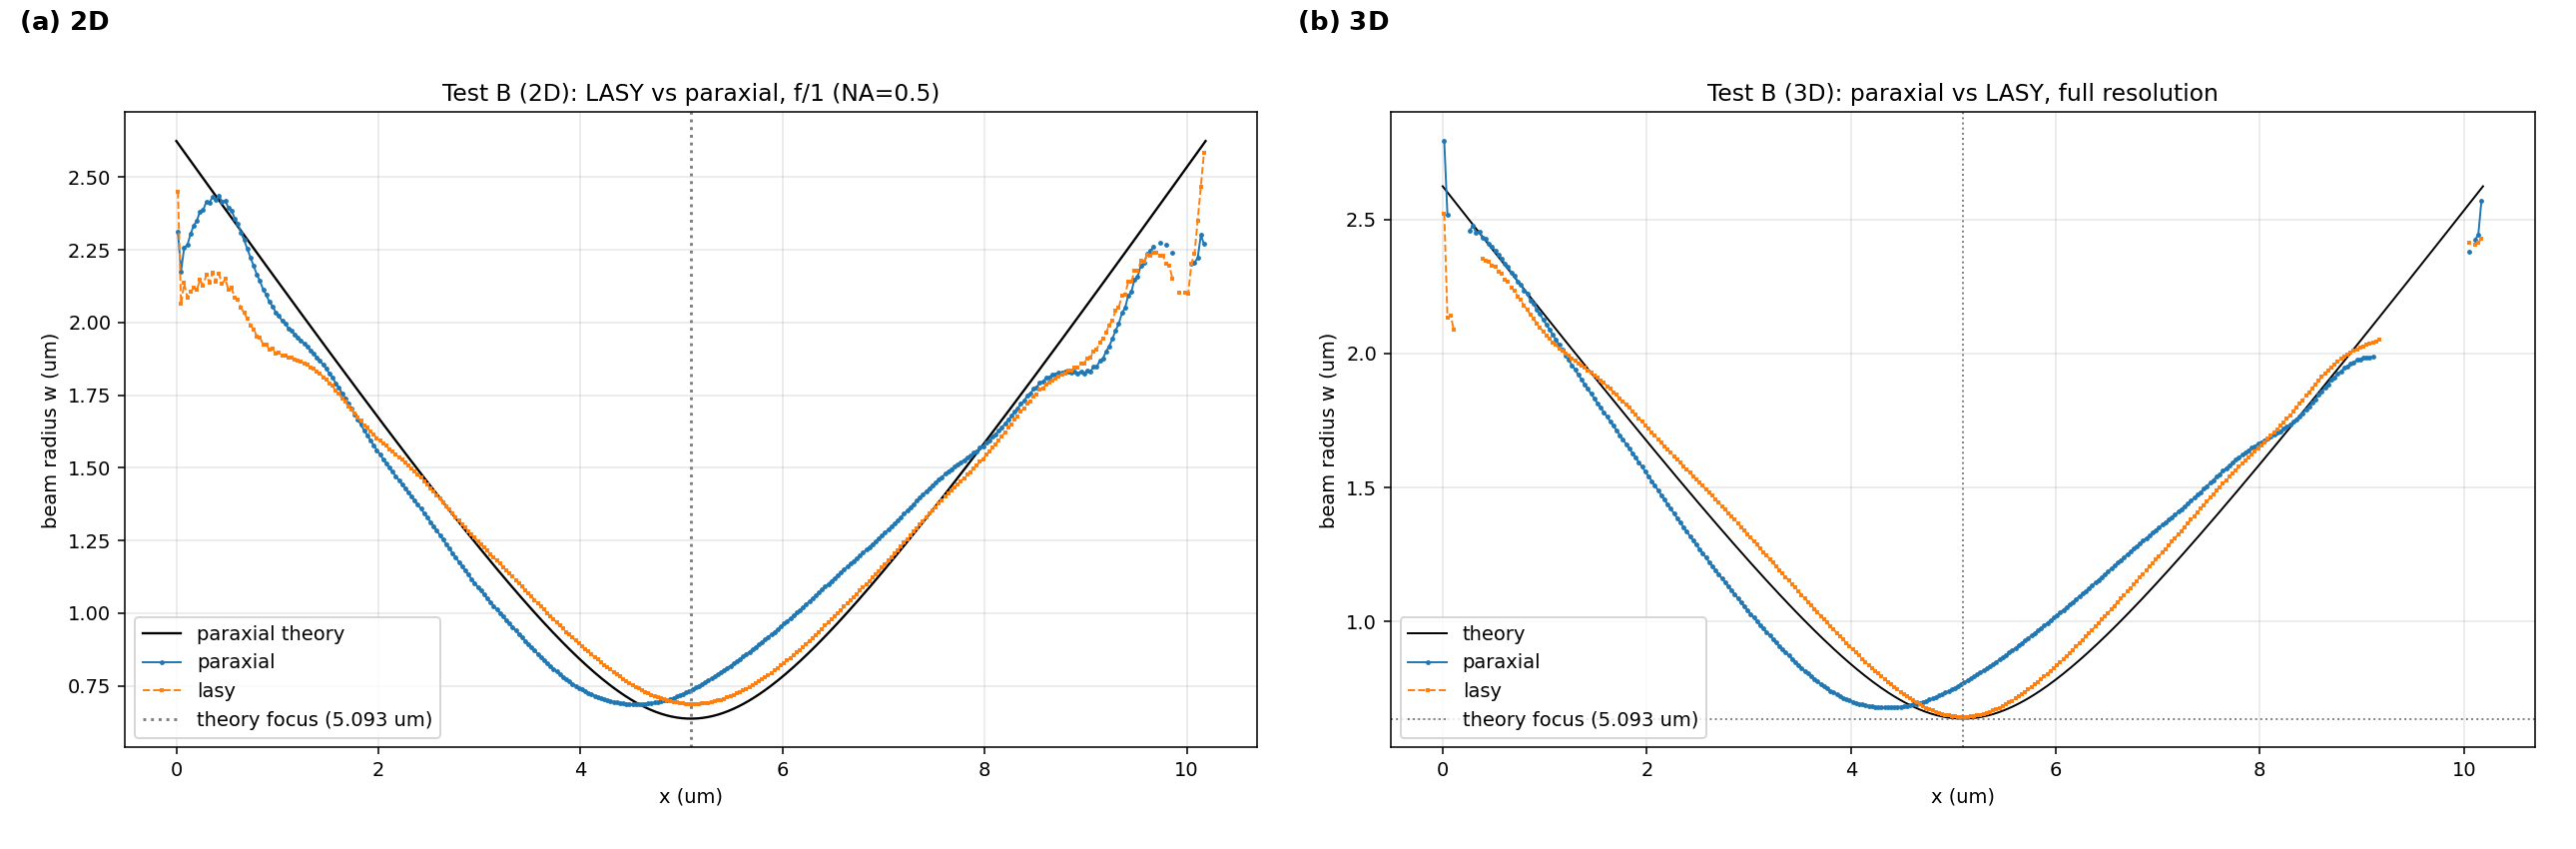

In [18]:
show(BASE, os.path.join('campaign_B_tight_focus_f1', 'campaign_B_waist_vs_x_collage.png'))

### Why is the 2D LASY result unreliable?

Both `generate_lasy.py` scripts call LASY's `dim="rt"` mode — a genuinely
**axisymmetric** (cylindrically-symmetric, 2-transverse-dimension)
propagator. That's the *only* non-paraxial mode LASY offers besides full 3D
Cartesian; there is no "1D-transverse slab" non-paraxial mode.

- **3D generator**: resamples the radial field onto a real Cartesian
  $(y,z)$ grid via $r=\sqrt{y^2+z^2}$ — an exact, physically self-consistent
  reconstruction of a true axisymmetric 3D beam. Correct geometry match to
  what epoch3d actually simulates.
- **2D generator**: instead slices the *same* axisymmetric radial field
  along $r=|y|$ and injects that directly as the 2D file. EPOCH2D is a
  genuinely **1D-transverse slab** (translationally invariant in $z$) — the
  pipeline already recognises this distinction for the *paraxial* generator
  (`GOUY_2D = 0.5 * GOUY_3D`, a dedicated half-Gouy-phase correction for the
  1D-transverse case), but that fix only corrects a spatially-uniform phase
  constant at the boundary. LASY's non-paraxial *amplitude* structure — the
  actual physics being probed at $f/1$ — is imported wholesale from the wrong
  (2-transverse-dimension) diffraction problem, with no equivalent
  correction available.

This plausibly explains both symptoms seen in the 2D plot: the deviation
concentrated right at focus (where non-paraxial effects are strongest, i.e.
exactly where the geometry mismatch matters most), and the reduced apparent
divergence away from focus (3D non-paraxial corrections act differently on
beam divergence than genuine 1D-transverse ones would).

**Practical consequence:** the 3D LASY-vs-paraxial comparison is the
trustworthy headline result. The 2D LASY row should be read as "a true-3D
non-paraxial beam force-injected into a 2D slab simulation" rather than a
genuine 2D non-paraxial reference. There is no quick fix within LASY itself
(no native 1D-transverse propagation mode) — a real fix needs a standalone
1D angular-spectrum (Rayleigh–Sommerfeld) propagator written by hand, or the
already-audited [Thiele propagator](../src/epoch_tools/field_propagator/thiele_injector.py)
(found mathematically sound in a prior round-trip/energy-conservation audit)
as a starting point.

### Caveat: raw-field comparison (`field_comparison.py` / `analytical_field.py`)

A newer diagnostic (animated analytical-vs-numerical-vs-difference $E$-field
triptychs) exists as a script here but is **not presented above**. Campaign B's
version compares the numerical field against a closed-form `analytical_field.py`
reference that had three bugs (boundary/focus amplitude normalisation, a
causality violation, and a width/amplitude-prefactor conflation) — all three
fixed, but the raw-field gap did **not** close afterwards: the analytical and
numerical fields still drift in and out of carrier phase along $x$ (a
near-half-cycle phase flip ~30× too large to be ordinary FDTD numerical
dispersion at this resolution). This points to a 4th, undiagnosed bug, most
likely in `analytical_field.py`'s carrier-propagation or wavefront-curvature
phase terms — **not yet chased down**. It does not affect anything above:
`analyse.py`'s Hilbert-envelope-based $w(x)$ fitting is insensitive to
carrier phase, so the headline Campaign B numbers stand regardless.

**Campaign B conclusion:** the paraxial approximation clearly breaks down
at $f/1$ in both 2D and 3D (10–15% RMS $w(x)$ disagreement with LASY), and
— more strikingly — the paraxial-injected beam focuses in the wrong place
by 10–15%, while LASY's non-paraxial injection lands the focus almost
exactly on target. The 3D result is the clean, trustworthy demonstration of
this; the 2D LASY numbers are contaminated by a geometry mismatch (LASY has
no native 1D-transverse-slab propagation mode) and should be read as
illustrative rather than quantitative.

---
## Summary

| Campaign | Cell | $x_{\mathrm{focus}}$ err. | $w_0$ err. | What it shows |
|---|---|---|---|---|
| A (2D) | injector vs.\ native, RMS $\Delta w(x)$ | — | $\le0.001\%$ | injector pipeline is exact |
| A (2D) | raw-field vs.\ native | — | 0.016% max | independent, stronger confirmation |
| A (3D) | injector vs.\ native, RMS $\Delta w(x)$ | — | $\le0.001\%$ | injector pipeline is exact in 3D too |
| B (2D) | paraxial vs.\ theory | +10.7% | +7.9% | paraxial breaks down at $f/1$ |
| B (2D) | LASY vs.\ theory | +0.4% | +8.0%$^\dagger$ | focus correct; width unreliable (geometry mismatch) |
| B (3D) | paraxial vs.\ theory | +14.5% | +6.6% | paraxial breaks down at $f/1$, worse in 3D |
| B (3D) | LASY vs.\ theory | +0.03% | +1.0% | non-paraxial injection is accurate |

$^\dagger$See "Why is the 2D LASY result unreliable?" above.

**Bottom line:** the file-injection pipeline itself (Campaign A) is
validated to $\le0.001\%$ in both 2D and 3D. Campaign B demonstrates that a
genuinely non-paraxial injected wavefront (LASY) is needed once NA becomes
large — the paraxial closed-form injection is not just quantitatively off
but qualitatively wrong about *where* the beam focuses, and this is cleanly
resolved by LASY in 3D (the geometrically self-consistent case).